# Identifying Keywords About Climate Change

First, we will apply Latent Dirichlet Allocation (LDA) on Integovernmental Panel on Climate Change (IPCC) reports to extract keywords about climate change. LDA is a generative probabilistic model and view each document as random mixtures over latent topics, in which each topic is a probaiblity distribution over a fixed vocabulary. 
LDA can discover topics that the documents contain and the extent to which these topics are included in each document. Thus, it identifies words that are highly present in a large number of IPCC reports. 

## Loading Data

To illustrate the process of LDA, we will first test it on a report from the TCFD. 

In [ ]:
#To be run only the first time to download the libraries
!pip install spacy
!pip install gensim 
!pip install nltk

In [ ]:
import nltk
nltk.download('stopwords')
import re
import numpy as np
from pprint import pprint
import spacy
from pandera.typing import DataFrame, DateTime, Object, Series
import pandera as pa
import gensim 
from nltk.corpus import stopwords
import gensim.corpora as corpora
import pandas as pd

In [145]:

filePath = 'E06 - Climate related risks and opportunities.txt'
report = sum(pd.read_table(filePath).values.tolist(), [])
report = ' '.join(report)

## Preprocessing


### Tokenizing

We need to tokenize the document into a list of words, remove the punctuations and unnecessary characters altogether. To do so, we will use Gensim's 'simple_preprocess()' function. Additionally, we have set 'deacc = True' to remove the punctuations.

In [179]:
def sent_to_words(doc:str) -> list:
    return gensim.utils.simple_preprocess(str(doc), deacc=True)

words = sent_to_words(report)
print(words[0:10])

['task_force', 'demand', 'investor_lender', 'stakeholder', 'information', 'disclosure', 'investor_lender', 'stakeholder', 'metric', 'information']


### Removing stopwords

We need to remove stopwords such as 'and', 'or', 'the'.

In [180]:
def remove_stopwords(words:list) -> list:
    stop_words = stopwords.words('english')
    stop_words.extend(['from', 'subject', 're', 'edu', 'use','risk','organization','climate','impact','change'])
    return [word for word in words if word not in stop_words]

report = remove_stopwords(words)
print(report[0:10])

['task_force', 'demand', 'investor_lender', 'stakeholder', 'information', 'disclosure', 'investor_lender', 'stakeholder', 'metric', 'information']


### Lemmatization

We next lemmatize each word to its root form, keeping only nouns. We want to keep only nouns because we are trying to extract the vocabulary regarding climate change risks.

In [ ]:
!python3 -m spacy download en # to be run only once 

In [181]:
def lemmatization(doc:list, allowed_postags = ['NOUN']) -> list:
    nlp = spacy.load('en_core_web_sm', disable = ['parser','ner'])
    texts_out = []
    doc = nlp(" ".join(doc))
    texts_out = [token.lemma_ for token in doc if token.pos_ in allowed_postags]
    return remove_stopwords(texts_out)

report = lemmatization(report)
print(report[0:10])

C:\Users\tlorans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\spacy\language.py:1895: UserWarning: [W123] Argument disable with value ['parser', 'ner'] is used instead of ['senter'] as specified in the config. Be aware that this might affect other components in your pipeline.
  warnings.warn(


['task_force', 'demand', 'information', 'disclosure', 'information', 'analysis', 'disclosure', 'framework', 'jurisdiction', 'effort']


### Bigrams

Finally, we group words seen frequently next to each other, to get pairs of words (bigrams).

In [182]:
def make_bigrams(report:list) -> list:
    bigram = gensim.models.Phrases([report], min_count=1, threshold=50) # higher threshold fewer phrases.
    bigram_mod = gensim.models.phrases.Phraser(bigram)
    return bigram_mod[report]

report = make_bigrams(report)
print(report[0:10])

['task_force', 'demand', 'information', 'disclosure', 'information', 'analysis', 'disclosure', 'framework', 'jurisdiction', 'effort']


## Exploratory Data Analysis

To get a sens of the result with our preprocessing, we'll make a word cloud using the wordcloud package. We'll get a visual representation of most common words.

In [10]:
from wordcloud import WordCloud

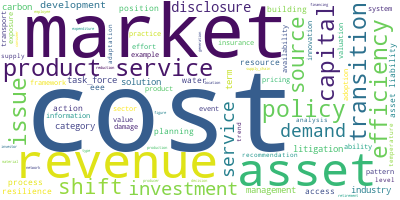

In [183]:
# Join the different processed titles together.
text = ','.join(report)
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(text)
# Visualize the word cloud
wordcloud.to_image()

## Build the Topic Model

To build a LDA model with Gensim, we need a corpus and a dictionary. 

In [184]:
id2word = corpora.Dictionary([report])
corpus = [id2word.doc2bow(report)]

In [186]:
lda_model = gensim.models.ldamodel.LdaModel(corpus = corpus,
                                            id2word = id2word, 
                                            num_topics = 2,
                                            random_state = 100,
                                            alpha = 2)
print(lda_model.print_topics())

[(0, '0.021*"service" + 0.020*"asset" + 0.019*"cost" + 0.016*"revenue" + 0.015*"market" + 0.015*"transition" + 0.014*"product" + 0.012*"policy" + 0.012*"capital" + 0.011*"efficiency"'), (1, '0.020*"asset" + 0.019*"service" + 0.018*"cost" + 0.018*"product" + 0.018*"market" + 0.017*"revenue" + 0.012*"issue" + 0.012*"efficiency" + 0.011*"capital" + 0.010*"policy"')]
